In [ ]:
import spacy
from spacy.tokens import DocBin
from tqdm import tqdm
import xml.etree.ElementTree as ET
from bs4 import BeautifulSoup
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import numpy as np
from spacy.tokens import DocBin
import spacy


In [ ]:
!wget --content-disposition "https://archive.org/download/stackexchange/math.stackexchange.com.7z"

!ls -lh
!apt-get install -y p7zip-full
!7z l math.stackexchange.com.7z
!mkdir data
!7z x math.stackexchange.com.7z Posts.xml -odata

!ls -lh data/Posts.xml

In [ ]:
# Download the larger English model to use as a base or for comparison
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Data Loading and Preprocessing

**Key Change**: We now treat tags as **classification labels**, not entity spans.

In [ ]:
xml_file = "data/Posts.xml"

def clean_html(raw_html):
    """Remove HTML tags and clean text."""
    if not raw_html:
        return ""
    soup = BeautifulSoup(raw_html, "html.parser")
    text = soup.get_text(separator=" ")
    # Clean up whitespace
    text = " ".join(text.split())
    return text

def parse_tags(tag_string):
    """Parse Stack Exchange tag format: '|tag1|tag2|tag3|' -> ['tag1', 'tag2', 'tag3']"""
    if not tag_string:
        return []
    # Split by pipe and filter empty strings
    tags = [tag.strip() for tag in tag_string.split('|') if tag.strip()]
    return tags

def load_data(xml_path, limit=None):
    """
    Load Stack Exchange posts and convert to text classification format.

    Returns:
        List of (text, categories) tuples where categories is a dict like:
        {"pythagorean-theorem": 1.0, "geometry": 1.0}
    """
    examples = []
    total_posts = 0
    posts_with_allowed_tags = 0

    # Parse XML
    tree = ET.parse(xml_path)
    root = tree.getroot()

    for post in tqdm(root.findall('.//row'), desc="Loading posts"):
        # Only process questions (PostTypeId="1")
        if post.get('PostTypeId') != '1':
            continue

        total_posts += 1

        # Extract text from Body
        body = post.get('Body', '')
        text = clean_html(body)

        # Skip empty or very short posts
        if len(text.strip()) < 20:
            continue

        # Parse tags
        tag_string = post.get('Tags', '')
        all_tags = parse_tags(tag_string)

        # Filter to only allowed topics
        filtered_tags = [tag for tag in all_tags if tag in ALLOWED_TOPICS]

        # Skip posts without any allowed tags
        if not filtered_tags:
            continue

        # Convert to category dict (multilabel format)
        cats = {tag: 1.0 for tag in filtered_tags}

        examples.append((text, cats))
        posts_with_allowed_tags += 1

        if limit and len(examples) >= limit:
            break

    print(f"\nTotal question posts: {total_posts}")
    print(f"Posts with allowed topics: {posts_with_allowed_tags} ({100*posts_with_allowed_tags/max(total_posts,1):.1f}%)")
    print(f"Loaded {len(examples)} training examples")

    if examples:
        sample = examples[0]
        print(f"\nSample: {{'text': '{sample[0][:100]}...', 'categories': {sample[1]}}}")

    return examples

# Load data (limit to 2000 for faster experimentation)
data = load_data(xml_file, 2000)

Loading posts:   1%|          | 19431/3792435 [00:05<18:53, 3329.70it/s]



Total question posts: 6429
Posts with allowed topics: 2000 (31.1%)
Loaded 2000 training examples

Sample: {'text': 'I'm told by smart people that $$0.999999999\ldots=1$$ and I believe them, but is there a proof that ...', 'categories': {'real-analysis': 1.0}}


## 3. Prepare Data for Spacy (DocBin)

**Key Change**: We use `doc.cats` instead of `doc.ents`.

In [ ]:
nlp = spacy.blank("en")
doc_bin = DocBin()

valid_examples = 0
skipped_examples = 0

for text, cats in tqdm(data, desc="Creating docs"):
    # Create doc
    doc = nlp.make_doc(text)

    # Set categories (this is the key difference from NER!)
    doc.cats = cats

    # Add to DocBin
    doc_bin.add(doc)
    valid_examples += 1

print(f"\nProcessed {valid_examples} valid examples")

# Save full dataset
doc_bin.to_disk("all_data.spacy")
print("Saved to all_data.spacy")

Creating docs: 100%|██████████| 2000/2000 [00:02<00:00, 847.44it/s] 



Processed 2000 valid examples
Saved to all_data.spacy


## 4. Train/Dev Split

Split the data into training and development sets.

In [ ]:
# Reload to split
full_doc_bin = DocBin().from_disk("all_data.spacy")
docs = list(full_doc_bin.get_docs(nlp.vocab))
random.shuffle(docs)

train_size = int(len(docs) * 0.8)
train_docs = docs[:train_size]
dev_docs = docs[train_size:]

train_bin = DocBin(docs=train_docs)
train_bin.to_disk("train.spacy")

dev_bin = DocBin(docs=dev_docs)
dev_bin.to_disk("dev.spacy")

print(f"Training docs: {len(train_docs)}, Dev docs: {len(dev_docs)}")

Training docs: 1600, Dev docs: 400


Loaded 11166 training docs and 2812 dev docs
Total labels: 75

✓ Visualization saved as 'dataset_analysis.png'


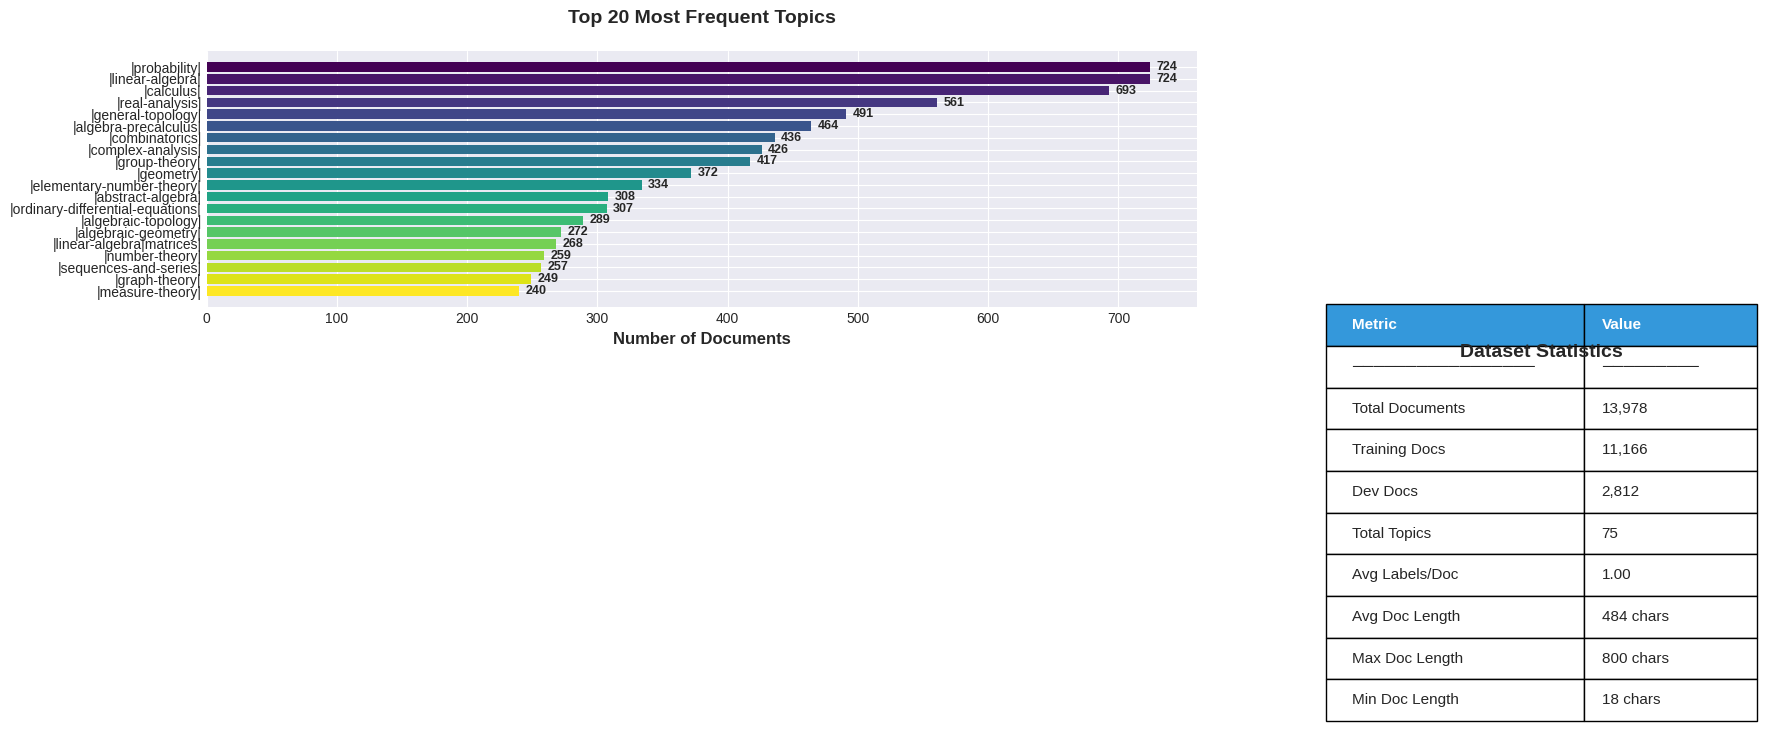

In [ ]:

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
nlp = spacy.blank("en")
train_docbin = DocBin().from_disk("train.spacy")
dev_docbin = DocBin().from_disk("dev.spacy")

train_docs = list(train_docbin.get_docs(nlp.vocab))
dev_docs = list(dev_docbin.get_docs(nlp.vocab))

# Load labels
with open('labels.json', 'r') as f:
    all_labels = json.load(f)

print(f"Loaded {len(train_docs)} training docs and {len(dev_docs)} dev docs")
print(f"Total labels: {len(all_labels)}")

# Create figure with subplots
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ==================== 1. TOPIC FREQUENCY DISTRIBUTION ====================
ax1 = fig.add_subplot(gs[0, :2])

# Count topic occurrences
topic_counts = Counter()
for doc in train_docs + dev_docs:
    for label, score in doc.cats.items():
        if score > 0.5:
            topic_counts[label] += 1

# Get top 20 topics
top_topics = topic_counts.most_common(20)
topics, counts = zip(*top_topics)

bars = ax1.barh(range(len(topics)), counts, color=plt.cm.viridis(np.linspace(0, 1, len(topics))))
ax1.set_yticks(range(len(topics)))
ax1.set_yticklabels(topics, fontsize=10)
ax1.set_xlabel('Number of Documents', fontsize=12, fontweight='bold')
ax1.set_title('Top 20 Most Frequent Topics', fontsize=14, fontweight='bold', pad=20)
ax1.invert_yaxis()

# Add value labels
for i, (topic, count) in enumerate(top_topics):
    ax1.text(count + 5, i, str(count), va='center', fontsize=9, fontweight='bold')

# ==================== 5. DATASET STATISTICS TABLE ====================
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

stats = [
    ['Metric', 'Value'],
    ['─────────────────', '─────────'],
    ['Total Documents', f"{len(train_docs) + len(dev_docs):,}"],
    ['Training Docs', f"{len(train_docs):,}"],
    ['Dev Docs', f"{len(dev_docs):,}"],
    ['Total Topics', f"{len(all_labels)}"],
    ['Avg Labels/Doc', f"{np.mean(labels_per_doc):.2f}"],
    ['Avg Doc Length', f"{np.mean(doc_lengths):.0f} chars"],
    ['Max Doc Length', f"{max(doc_lengths):,} chars"],
    ['Min Doc Length', f"{min(doc_lengths):,} chars"],
]

table = ax5.table(cellText=stats, cellLoc='left', loc='center',
                  colWidths=[0.6, 0.4],
                  cellColours=[['#E8F8F5']*2] + [['white']*2]*9)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(2):
    table[(0, i)].set_facecolor('#3498DB')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax5.set_title('Dataset Statistics', fontsize=14, fontweight='bold', pad=20)


print("\n✓ Visualization saved as 'dataset_analysis.png'")

## 5. Configuration

**Key Change**: Pipeline uses `textcat_multilabel` instead of `ner`.

Why multilabel?
- Math texts often span multiple concepts
- A post about Pythagorean theorem might also involve trigonometry and geometry

In [ ]:
base_config_content = f"""
[paths]
train = null
dev = null
vocab = null
vectors = "en_core_web_lg"
init_tok2vec = null

[system]
gpu_allocator = null
system_seed = 0

[nlp]
lang = "en"
pipeline = ["textcat_multilabel"]
batch_size = 1000

[components]

[components.textcat_multilabel]
factory = "textcat_multilabel"

[components.textcat_multilabel.model]
@architectures = "spacy.TextCatEnsemble.v2"
nO = {len(ALLOWED_TOPICS)}

[components.textcat_multilabel.model.tok2vec]
@architectures = "spacy.Tok2Vec.v2"

[components.textcat_multilabel.model.tok2vec.embed]
@architectures = "spacy.MultiHashEmbed.v2"
width = 96
attrs = ["NORM","PREFIX","SUFFIX","SHAPE"]
rows = [5000,2500,2500,2500]
include_static_vectors = false

[components.textcat_multilabel.model.tok2vec.encode]
@architectures = "spacy.MaxoutWindowEncoder.v2"
width = 96
depth = 4
window_size = 1
maxout_pieces = 3


[components.textcat_multilabel.model.linear_model]
@architectures = "spacy.TextCatBOW.v2"
exclusive_classes = false
ngram_size = 1
no_output_layer = false
nO = {len(ALLOWED_TOPICS)}

[corpora]

[corpora.train]
@readers = "spacy.Corpus.v1"
path = ${{paths.train}}
max_length = 0
gold_preproc = false
limit = 0
augmenter = null

[corpora.dev]
@readers = "spacy.Corpus.v1"
path = ${{paths.dev}}
max_length = 0
gold_preproc = false
limit = 0
augmenter = null

[training]
dev_corpus = "corpora.dev"
train_corpus = "corpora.train"
system_seed = ${{system.system_seed}}
gpu_allocator = ${{system.gpu_allocator}}
dropout = 0.3
accumulate_gradient = 1
patience = 3
max_epochs = 20
max_steps = 0
eval_frequency = 2
frozen_components = []
annotating_components = []
before_to_disk = null

[training.batcher]
@batchers = "spacy.batch_by_words.v1"
discard_oversize = false
tolerance = 0.2
get_length = null

[training.batcher.size]
@schedules = "compounding.v1"
start = 100
stop = 1000
compound = 1.001
t = 0.0

[training.logger]
@loggers = "spacy.ConsoleLogger.v1"
progress_bar = false

[training.optimizer]
@optimizers = "Adam.v1"
beta1 = 0.9
beta2 = 0.999
L2_is_weight_decay = true
L2 = 0.01
grad_clip = 1.0
use_averages = false
eps = 0.00000001
learn_rate = 0.001

[training.score_weights]
cats_score = 1.0
cats_score_desc = null
cats_micro_p = null
cats_micro_r = null
cats_micro_f = null
cats_macro_p = null
cats_macro_r = null
cats_macro_f = null
cats_macro_auc = null
cats_f_per_type = null
cats_macro_auc_per_type = null
"""

with open("base_config.cfg", "w") as f:
    f.write(base_config_content)

print("Created base_config.cfg for text classification")

NameError: name 'ALLOWED_TOPICS' is not defined

In [ ]:
!python -m spacy init config config.cfg --lang en --pipeline textcat_multilabel --optimize efficiency

⚠ To generate a more effective transformer-based config (GPU-only),
install the spacy-transformers package and re-run this command. The config
generated now does not use transformers.
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: textcat_multilabel
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


## 6. Training

Text categorization typically converges faster than NER.

In [ ]:
!python -m spacy init fill-config base_config.cfg config.cfg

In [ ]:
import json

with open('labels.json', 'r') as f:
    labels = json.load(f)

print(f"Found {len(labels)} labels")
print(f"First 10: {labels[:10]}")

Found 75 labels
First 10: ['|abstract-algebra|', '|abstract-algebra|field-theory|', '|abstract-algebra|group-theory|', '|abstract-algebra|ring-theory|', '|algebra-precalculus|', '|algebra-precalculus|inequality|', '|algebraic-geometry|', '|algebraic-geometry|commutative-algebra|', '|algebraic-number-theory|', '|algebraic-topology|']


In [ ]:
!python -m spacy train config.cfg \
    --output ./output \
    --paths.train ./train.spacy \
    --paths.dev ./dev.spacy \
    --gpu-id 0

ℹ Saving to output directory: output
ℹ Using GPU: 0

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['textcat_multilabel']
ℹ Initial learn rate: 0.001
E    #       LOSS TEXTC...  CATS_SCORE  SCORE 
---  ------  -------------  ----------  ------
  0       0           0.25       50.02    0.50
  0     200           5.56       51.04    0.51
  0     400           2.83       51.59    0.52
  0     600           2.76       51.92    0.52
  0     800           2.69       52.29    0.52
  0    1000           2.71       52.62    0.53
  0    1200           2.70       52.99    0.53
  0    1400           2.69       53.24    0.53
  0    1600           2.66       53.65    0.54
  0    1800           2.66       54.22    0.54
  0    2000           2.56       54.89    0.55
  0    2200           2.53       55.23    0.55
  0    2400           2.50       55.86    0.56

## 7. Evaluation

**Key Change**: We examine `doc.cats` instead of `doc.ents`.

In [ ]:
nlp_best = spacy.load("output/model-best")

# Test on various mathematical questions
test_texts = [
    "Explain why a^2 + b^2 = c^2 holds for right triangles",
    "What is the relationship between the sides of a right triangle?",
    "How do you compute the determinant of a 3x3 matrix?",
    "What is the derivative of sin(x)?",
    "Explain Bayes' theorem with an example",
    "What are prime numbers and how do you test for primality?"
]

print("\n" + "="*80)
print("TOPIC EXTRACTION RESULTS")
print("="*80 + "\n")

for text in test_texts:
    doc = nlp_best(text)

    print(f"Text: {text}")
    print(f"\nDetected topics:")

    # Sort by confidence score
    sorted_cats = sorted(doc.cats.items(), key=lambda x: x[1], reverse=True)

    # Show top 5 predictions
    for topic, score in sorted_cats[:5]:
        if score > 0.1:  # Only show if reasonably confident
            print(f"  - {topic}: {score:.3f}")

    # Get the most likely topic
    top_topic = max(doc.cats, key=doc.cats.get)
    print(f"\n  → Primary topic: {top_topic} ({doc.cats[top_topic]:.3f})")
    print("\n" + "-"*80 + "\n")


TOPIC EXTRACTION RESULTS

Text: Explain why a^2 + b^2 = c^2 holds for right triangles

Detected topics:
  - |algebra-precalculus|: 0.353
  - |linear-algebra|: 0.344
  - |trigonometry|: 0.312
  - |sequences-and-series|: 0.303
  - |elementary-number-theory|: 0.302

  → Primary topic: |algebra-precalculus| (0.353)

--------------------------------------------------------------------------------

Text: What is the relationship between the sides of a right triangle?

Detected topics:
  - |geometry|: 0.438
  - |algebra-precalculus|: 0.331
  - |trigonometry|: 0.317
  - |probability|: 0.238
  - |linear-algebra|: 0.226

  → Primary topic: |geometry| (0.438)

--------------------------------------------------------------------------------

Text: How do you compute the determinant of a 3x3 matrix?

Detected topics:
  - |linear-algebra|matrices|: 0.247
  - |linear-algebra|: 0.238
  - |trigonometry|: 0.223
  - |calculus|integration|: 0.169
  - |statistics|: 0.165

  → Primary topic: |linear-algebr

In [ ]:
import random
import re
import os
import shutil
from collections import Counter
from lxml import etree

import spacy
from spacy.tokens import DocBin

paths_to_clean = [
    'train.spacy',
    'dev.spacy',
    'all_data.spacy',
    'output/model-best',
    'output/model-last',
    'config.cfg',
    'base_config.cfg'
]

for path in paths_to_clean:
    if os.path.exists(path):
        if os.path.isdir(path):
            shutil.rmtree(path)
            print(f"Removed directory: {path}")
        else:
            os.remove(path)
            print(f"Removed file: {path}")

os.makedirs('output', exist_ok=True)

def stream_posts(xml_path):
    """Streams StackExchange Posts.xml efficiently."""
    context = etree.iterparse(xml_path, events=("end",), tag="row")
    for _, elem in context:
        yield elem.attrib
        elem.clear()

TAG_RE = re.compile(r"<[^>]+>")

def clean_html(text, max_chars=800):
    if not text:
        return ""
    text = TAG_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()[:max_chars]

def extract_tags(tag_string):
    if not tag_string:
        return []
    return tag_string.strip("<>").split("><")

# ============================================
# CONFIGURATION - ADJUST THESE!
# ============================================
SAMPLE_SIZE = 100000
MIN_FREQ = 50
MAX_TAGS_PER_DOC = 2
TRAIN_SPLIT = 0.8
# ============================================

print(f"Processing first {SAMPLE_SIZE:,} posts...")

# Step 1: Compute tag frequencies from sample
print("Step 1/3: Computing tag frequencies...")
tag_counter = Counter()
xml_path = "data/Posts.xml"

for i, post in enumerate(stream_posts(xml_path)):
    if i >= SAMPLE_SIZE:
        break
    tags = extract_tags(post.get("Tags", ""))
    tag_counter.update(tags)

    if (i + 1) % 1000 == 0:
        print(f"  Scanned {i + 1:,} posts...")

# Keep only frequent tags
ALLOWED_TAGS = sorted([
    tag for tag, freq in tag_counter.items()
    if freq >= MIN_FREQ
])

print(f"\nFound {len(ALLOWED_TAGS)} topics with at least {MIN_FREQ} occurrences")
print(f"Top 10 topics: {ALLOWED_TAGS[:10]}")

# Save labels for reference
import json
with open('labels.json', 'w') as f:
    json.dump(ALLOWED_TAGS, f, indent=2)
print("Saved labels to labels.json")

# Step 2: Create training data
print(f"\nStep 2/3: Creating train/dev data from {SAMPLE_SIZE:,} posts...")
nlp = spacy.blank("en")

train_db = DocBin(store_user_data=False)
dev_db = DocBin(store_user_data=False)

docs_created = 0
docs_skipped = 0

for i, post in enumerate(stream_posts(xml_path)):
    if i >= SAMPLE_SIZE:
        break

    text = clean_html(post.get("Body", ""))
    if not text:
        docs_skipped += 1
        continue

    tags = extract_tags(post.get("Tags", ""))
    tags = [t for t in tags if t in ALLOWED_TAGS][:MAX_TAGS_PER_DOC]
    if not tags:
        docs_skipped += 1
        continue

    doc = nlp.make_doc(text)

    # Initialize all labels to 0.0 (CRUCIAL for multilabel)
    doc.cats = {label: 0.0 for label in ALLOWED_TAGS}
    for tag in tags:
        doc.cats[tag] = 1.0

    if random.random() < TRAIN_SPLIT:
        train_db.add(doc)
    else:
        dev_db.add(doc)

    docs_created += 1

    if (i + 1) % 1000 == 0:
        print(f"  Processed {i + 1:,} posts ({docs_created} kept, {docs_skipped} skipped)...")

# Step 3: Save files
print("\nStep 3/3: Saving .spacy files...")
train_db.to_disk("train.spacy")
dev_db.to_disk("dev.spacy")

# Verify
train_count = len(list(DocBin().from_disk('train.spacy').get_docs(nlp.vocab)))
dev_count = len(list(DocBin().from_disk('dev.spacy').get_docs(nlp.vocab)))

print("\n" + "="*60)

print("="*60)
print(f"Sample size:       {SAMPLE_SIZE:,} posts")
print(f"Documents created: {docs_created:,}")
print(f"Documents skipped: {docs_skipped:,}")
print(f"Train set:         {train_count:,} examples")
print(f"Dev set:           {dev_count:,} examples")
print(f"Total topics:      {len(ALLOWED_TAGS)}")
print(f"Min frequency:     {MIN_FREQ}")
print("="*60)

Removed file: train.spacy
Processing first 100,000 posts...
Step 1/3: Computing tag frequencies...
  Scanned 1,000 posts...
  Scanned 2,000 posts...
  Scanned 3,000 posts...
  Scanned 4,000 posts...
  Scanned 5,000 posts...
  Scanned 6,000 posts...
  Scanned 7,000 posts...
  Scanned 8,000 posts...
  Scanned 9,000 posts...
  Scanned 10,000 posts...
  Scanned 11,000 posts...
  Scanned 12,000 posts...
  Scanned 13,000 posts...
  Scanned 14,000 posts...
  Scanned 15,000 posts...
  Scanned 16,000 posts...
  Scanned 17,000 posts...
  Scanned 18,000 posts...
  Scanned 19,000 posts...
  Scanned 20,000 posts...
  Scanned 21,000 posts...
  Scanned 22,000 posts...
  Scanned 23,000 posts...
  Scanned 24,000 posts...
  Scanned 25,000 posts...
  Scanned 26,000 posts...
  Scanned 27,000 posts...
  Scanned 28,000 posts...
  Scanned 29,000 posts...
  Scanned 30,000 posts...
  Scanned 31,000 posts...
  Scanned 32,000 posts...
  Scanned 33,000 posts...
  Scanned 34,000 posts...
  Scanned 35,000 posts...
